# AG-HYPOPT · Trial 16

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Fifteen trials are registered; cell 2 reports `phase = trials` (15/5), so proposals carry expected-improvement (ei) values. **Best = trial_08** (objective 0.1099). The picture (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- **trial_08 (0.1099, best):** travel 0.134.
- optimum region (all 0 div): trial_15 0.1103 (0.127), trial_12 0.1115 (0.128), trial_09 0.1126 (0.123), trial_01 0.1127 (0.120), trial_14 0.1127 (0.140), trial_13 0.1132 (0.134).
- slightly lower: trial_05 0.1135 (0.088), trial_07 0.1140 (0.097), trial_06 0.1188 (0.082), trial_11 0.1188 (0.159).
- diverging: trial_10 0.1975 (0.099), trial_03 0.1362 (0.074), trial_04 0.1418 (0.074), trial_02 0.1449 (0.264).

Ten divergence-free runs now populate a flat optimum at mu travel ~0.13; the six best sit within 0.003 of each other (0.1099-0.1132) and none of the gamma-knob variations among them has beaten trial_08. The residual errors are unchanged everywhere: mid-T mu overshoot (~+130% to +160%), 3nW high-T mu undershoot (~-22% to -37%), low-T gamma under-recovery (~-30% to -50%). Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_16'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (15/5 trials)
ID |     ei | params
 1 | 2.9764 | {"gamma_anneal": 0.5467934524301566, "lr_gamma": 0.3806755729141957, "lr_mu": 0.1488808914113843, "mu_anneal": 0.35808707507257653}
 2 | 0.5714 | {"gamma_anneal": 0.7221788665793137, "lr_gamma": 0.7108427191536644, "lr_mu": 0.34735177921171695, "mu_anneal": 0.3577461633976345}
 3 | 3.9647 | {"gamma_anneal": 0.5198219328315702, "lr_gamma": 0.46220559307171344, "lr_mu": 0.1690692270001428, "mu_anneal": 0.3491227345382648}
 4 | 0.4947 | {"gamma_anneal": 0.3462673606789698, "lr_gamma": 0.44511986736549947, "lr_mu": 0.1362763163637269, "mu_anneal": 0.729884858046672}
 5 | 3.4434 | {"gamma_anneal": 0.49416634825787414, "lr_gamma": 0.9757741646403011, "lr_mu": 0.15078586871618221, "mu_anneal": 0.35610908079103315}
 6 | 3.9686 | {"gamma_anneal": 0.46672441937626824, "lr_gamma": 0.4520499643693517, "lr_mu": 0.15527021754560388, "mu_anneal": 0.3506271637511188}
 7 | 3.3626 | {"gamma_anneal": 0.890282676020109, "lr_gamma": 0.4449579

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (15 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 6: **ei 3.97** — `lr_mu=0.155`, `mu_anneal=0.351` (travel **0.128**), `lr_gamma=0.452`, `gamma_anneal=0.467`.
- candidate 3: ei 3.96 — `lr_mu=0.169`, `mu_anneal=0.349` (travel 0.140), `lr_gamma=0.462`, `gamma_anneal=0.520`.
- candidate 5: ei 3.44 — `lr_mu=0.151`, `mu_anneal=0.356` (travel 0.124), `lr_gamma=0.976` (very high), `gamma_anneal=0.494`.
- candidate 7: ei 3.36 — `lr_mu=0.165`, `mu_anneal=0.341` (travel 0.137), `lr_gamma=0.445`, `gamma_anneal=0.890` (very high).
- candidate 1: ei 2.98 — `lr_mu=0.149`, `mu_anneal=0.358` (travel 0.122), `lr_gamma=0.381`.

The two highest-ei candidates (6, 3) both sit on the flat optimum at travel 0.128 and 0.140, with gamma knobs (`lr_gamma` ~0.45, `gamma_anneal` ~0.47-0.52) matching the proven-safe range of the divergence-free runs. Candidate 6 is the maximum-ei point and its mu knobs are essentially trial_15/trial_08's; it is a straightforward, low-risk resample of the best region. The other near-top candidates carry untested extremes (candidate 5 `lr_gamma=0.976`, candidate 7 `gamma_anneal=0.890`) and candidate 1 sits slightly lower on travel. Given the plateau, the maximum-ei candidate is the natural pick; there is no evidence favouring a different region.

I choose candidate 6 (6 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 6            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.46672441937626824, 'lr_gamma': 0.4520499643693517, 'lr_mu': 0.15527021754560388, 'mu_anneal': 0.3506271637511188}
Running  1nW Trans05 ... 

μ 9.39 -> 10.21 | γ 8.5 -> 4.55 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 42.51 | γ 8.5 -> 6.09 | NLL 5.34


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 75.73 | γ 14.1 -> 14.43 | NLL 3.40


Running 3nW Trans100 ... 

μ 175.71 -> 110.52 | γ 14.1 -> 14.03 | NLL 3.18



Total: 7.8 min


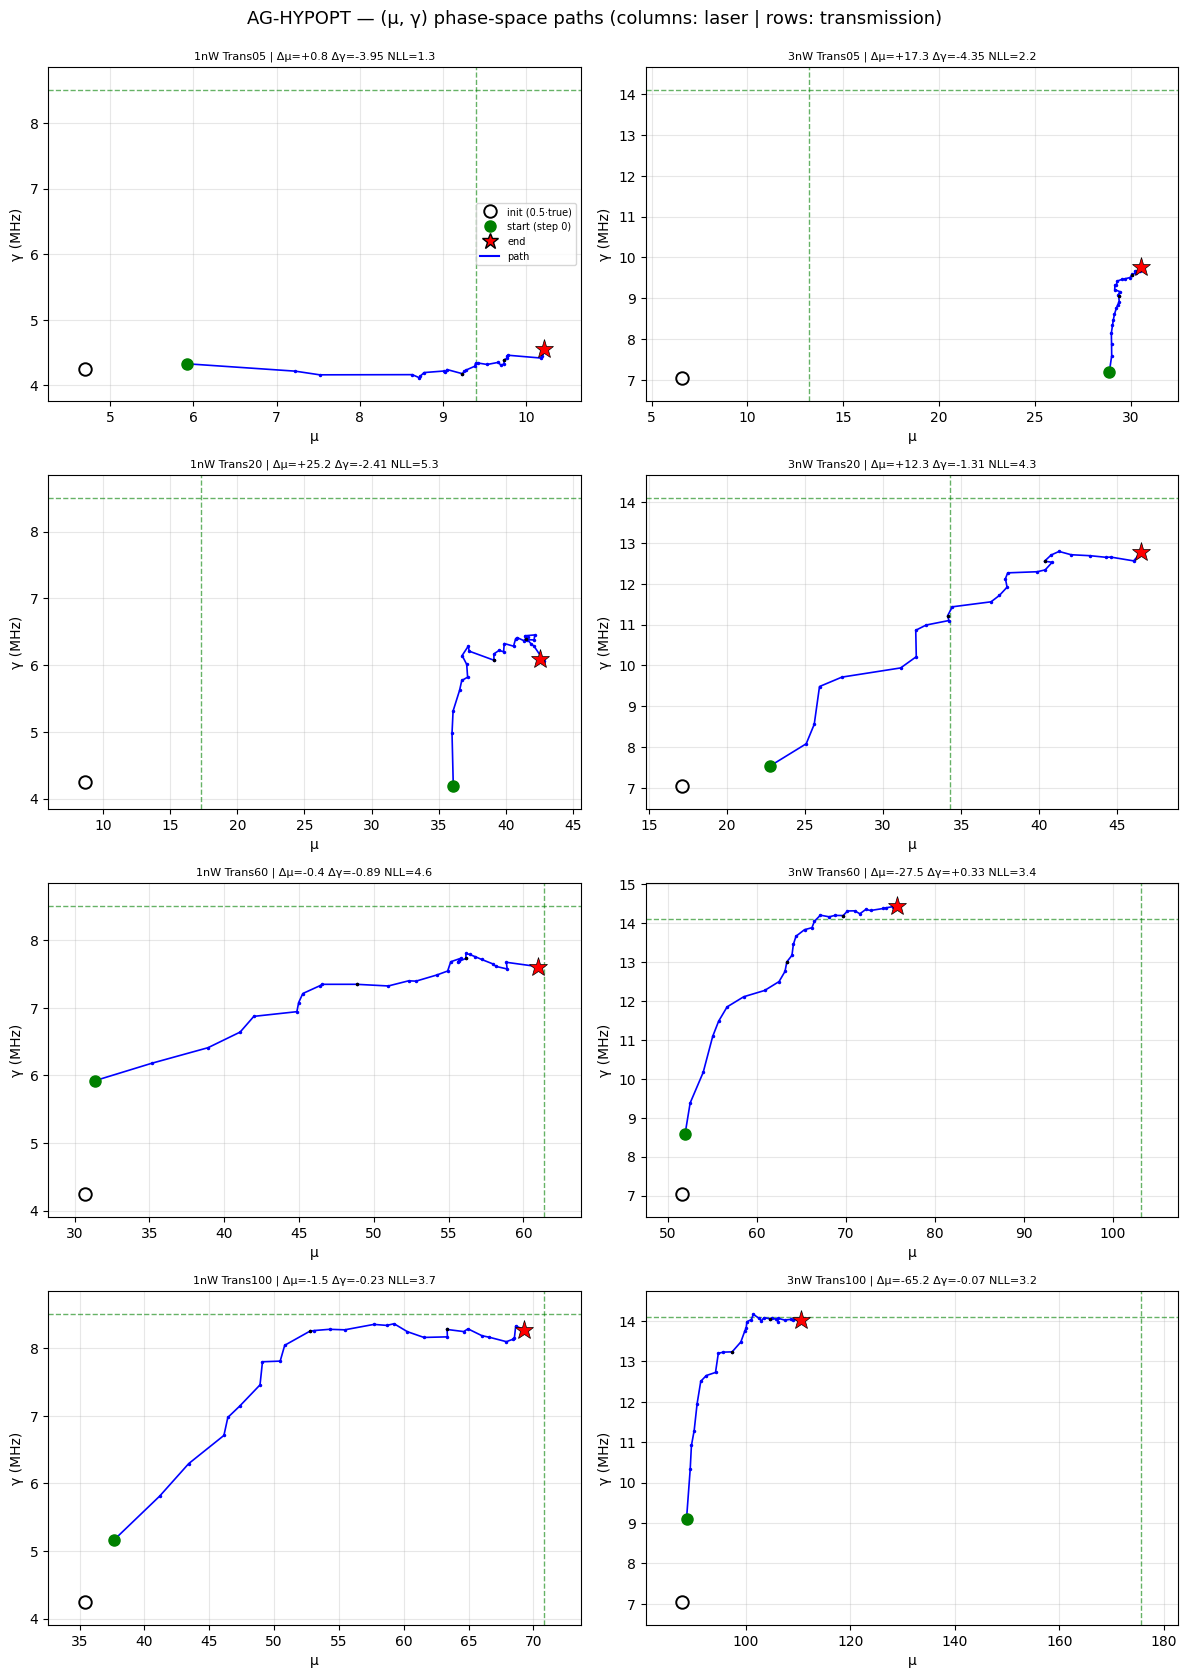

trial finished in 7.9 min
objective = 0.1112 ± 0.0824
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.21    +8.7 |     8.50    4.55   -46.5
1nW Trans20       17.32   42.51  +145.5 |     8.50    6.09   -28.3
1nW Trans60       61.37   60.94    -0.7 |     8.50    7.61   -10.5
1nW Trans100       70.82   69.29    -2.2 |     8.50    8.27    -2.7
3nW Trans05       13.20   30.54  +131.3 |    14.10    9.75   -30.8
3nW Trans20       34.28   46.54   +35.8 |    14.10   12.79    -9.3
3nW Trans60      103.20   75.73   -26.6 |    14.10   14.43    +2.3
3nW Trans100      175.71  110.52   -37.1 |    14.10   14.03    -0.5

weighted objective (T-graded, cap=1.0) = 0.1112 | diverged cells: 0
μ: RMSE 27.598 (rel 72.3%, bias -4.878) | γ: RMSE 2.317 (rel 22.7%, bias -1.609)


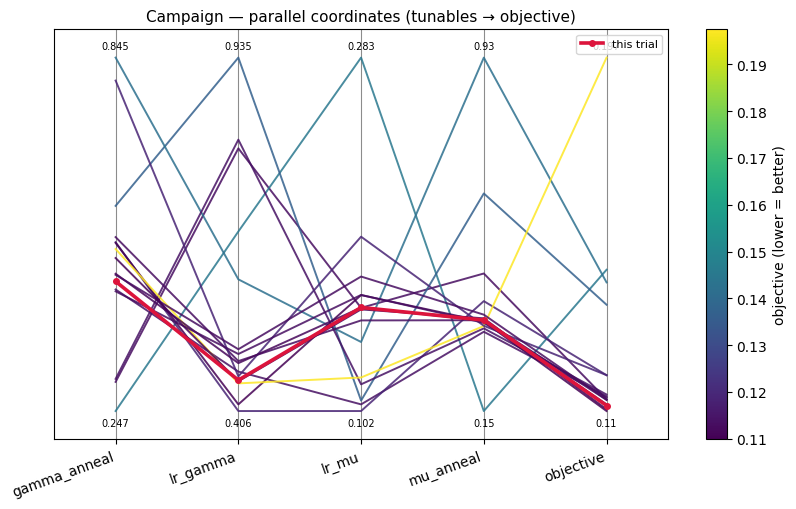

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 16 ran the highest-EI candidate (candidate 6, ei=3.97): `lr_mu=0.1553`, `mu_anneal=0.3506` (effective mu travel 0.128), `lr_gamma=0.4520`, `gamma_anneal=0.4667`. It completed in 7.9 min with objective **0.1112 +/- 0.0824** and **0 diverged cells** — third-best. Ranking: trial_08 0.1099 < trial_15 0.1103 < **trial_16 0.1112** < trial_12 0.1115 < trial_09 0.1126 < trial_01 = trial_14 0.1127 < trial_13 0.1132 < ...

Aggregate accuracy: **mu rel-RMSE 72.3%** (RMSE 27.60, bias -4.88); **gamma rel-RMSE 22.7%** (RMSE 2.32, bias -1.61).

Per-cell relative errors:
- **mu:** 1nW T05 +8.7%, T20 +145.5%, T60 -0.7%, T100 -2.2% | 3nW T05 +131.3%, T20 +35.8%, T60 -26.6%, T100 -37.1%.
- **gamma:** 1nW T05 -46.5%, T20 -28.3%, T60 -10.5%, T100 -2.7% | 3nW T05 -30.8%, T20 -9.3%, T60 +2.3%, T100 -0.5%.

Another maximum-ei sample placed right on the optimum (travel 0.128), and it landed at 0.1112 — third-best, again inside the same 0.1099-0.1132 cluster. Its 1nW high-T cells were excellent (T60 -0.7%, T100 -2.2%) and gamma was clean everywhere it has been before; the mid-T overshoots (1nW T20 +145.5%, 3nW T05 +131.3%) and 3nW high-T undershoot (-26.6% / -37.1%) are unchanged. This is the seventh sub-0.113 sample; the objective surface around the optimum has now been sampled very densely and remains flat, with trial_08's exact point still the lowest.

**Summary:** Trial 16 (lr_mu=0.1553, mu_anneal=0.3506, lr_gamma=0.4520, gamma_anneal=0.4667): objective 0.1112 +/- 0.0824 with 0 diverged cells; yet another optimum-region sample (travel 0.128) landed third-best, so the plateau holds and trial_08 (0.1099) is unchanged as best.
**Key insight:** The optimum region keeps returning 0.1099-0.1132 regardless of the gamma-knob details; with seven sub-0.113 samples now, the campaign is plateaued and trial_08 remains the best.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** This is the clearest plateau statement yet: eleven divergence-free runs, the best seven within 0.004, and every knob variation returns the same residual errors. The campaign is essentially done exploring this schedule family; the remaining ~0.110 is set by structural features (mid-T overshoot, 3nW high-T undershoot, low-T gamma under-recovery) the four knobs cannot reach. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 16 (lr_mu=0.1553, mu_anneal=0.3506, lr_gamma=0.4520, gamma_anneal=0.4667): objective 0.1112 +/- 0.0824 with 0 diverged cells; yet another optimum-region sample (travel 0.128) landed third-best, so the plateau holds and trial_08 (0.1099) is unchanged as best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The optimum region keeps returning 0.1099-0.1132 regardless of the gamma-knob details; with seven sub-0.113 samples now, the campaign is plateaued and trial_08 remains the best"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_16 | current best: trial_08


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_17.ipynb. Open it and follow its cells from the top.
